# Pose correction — stacked LSTM with embedding layers

Same regression task as `TFT_pose_correction.ipynb`: predict the **final joint displacement** (`12 * n_coords`, typically **36**, or **24** with `--drop-z`) from a short pose window.

**Inputs**
- **Pose sequence** `(T, 12 * n_coords)` — normalized per feature over the dataset (continuous); `n_coords` comes from metadata.
- **Workout class id** (integer) — passed through an **`Embedding`** instead of concatenating one-hot pose features.
- **Timestep index** `0 … T−1` — second **`Embedding`** so the LSTM sees explicit position in the window.

**Head**
Per-step features = concat(pose, broadcast class embedding, time embedding) → **TimeDistributed** linear projection → **two LSTM** layers (sequence output) → **GlobalAveragePooling1D** → small MLP → **`12 * n_coords` outputs**.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks, layers, models

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")


def r2_score_np(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true, axis=0, keepdims=True)) ** 2))
    return 1.0 - ss_res / (ss_tot + 1e-12)


TensorFlow version: 2.21.0
Keras version: 3.14.0


## Load displacement training data

In [2]:
data_path = Path("../../Data/output_displacement/training_data_displacement.npz")
metadata_path = Path("../../Data/output_displacement/training_data_displacement_metadata.json")

with open(metadata_path, "r") as f:
    metadata = json.load(f)

print("Dataset metadata:")
for k in (
    "n_samples",
    "sequence_length",
    "n_landmarks",
    "X_pose_flat_dim",
    "X_class_dim",
    "y_final_disp_flat_dim",
    "class_encoding",
):
    print(f"  {k}: {metadata[k]}")
print(f"  n_coords: {metadata.get('n_coords', 3)}  (older JSON without key defaults to 3)")

data = np.load(data_path, allow_pickle=True)
print(f"\n.npz keys: {list(data.keys())}")

X = data["X"].astype(np.float32)
y = data["y"].astype(np.float32)
y_class = data["y_class"].astype(np.int32)
class_names = data["class_names"]

n_classes = int(len(class_names))
print(f"\nX: {X.shape}, y: {y.shape}, y_class: {y_class.shape}, classes: {n_classes}")


Dataset metadata:
  n_samples: 58820
  sequence_length: 15
  n_landmarks: 12
  X_pose_flat_dim: 360
  X_class_dim: 17
  y_final_disp_flat_dim: 24
  class_encoding: onehot
  n_coords: 2  (older JSON without key defaults to 3)

.npz keys: ['X', 'y', 'y_class', 'y_class_onehot', 'y_class_raw', 'class_names', 'n_landmarks', 'n_coords', 'sequence_length']

X: (58820, 377), y: (58820, 24), y_class: (58820,), classes: 17


## Preprocess (pose-only normalization + standardized targets)

Unlike the TFT notebook, **one-hot class features are not part of the sequence tensor**. Class is carried as an integer and embedded in the model. Only the **`12 * n_coords` pose values per frame** are z-scored (`n_coords` from metadata).

In [3]:
N = int(X.shape[0])
T = int(metadata["sequence_length"])
pose_flat_dim = int(metadata["X_pose_flat_dim"])

X_pose_flat = X[:, :pose_flat_dim]
X_pose_seq = X_pose_flat.reshape(N, T, -1)
n_coords = int(metadata.get("n_coords", 3))
n_landmarks = int(metadata["n_landmarks"])
pose_feats_per_step = n_landmarks * n_coords
if X_pose_seq.shape[2] != pose_feats_per_step:
    raise ValueError(
        f"Expected {pose_feats_per_step} pose features per timestep "
        f"(n_landmarks={n_landmarks} * n_coords={n_coords}), got {X_pose_seq.shape[2]}"
    )

X_pose_seq = np.nan_to_num(X_pose_seq, nan=0.0, posinf=0.0, neginf=0.0)
y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

X_mean = np.mean(X_pose_seq, axis=(0, 1), keepdims=True)
X_std = np.std(X_pose_seq, axis=(0, 1), keepdims=True) + 1e-8
X_pose_norm = (X_pose_seq - X_mean) / X_std

y_mean = np.mean(y, axis=0, keepdims=True)
y_std = np.std(y, axis=0, keepdims=True) + 1e-8
y_standardized = (y - y_mean) / y_std

print(f"X_pose_norm: {X_pose_norm.shape}, y_standardized: {y_standardized.shape}")


X_pose_norm: (58820, 15, 24), y_standardized: (58820, 24)


## Train / test split (stratified by workout class)

In [4]:
from sklearn.model_selection import train_test_split

X_pose_train, X_pose_test, y_train, y_test, y_class_train, y_class_test = train_test_split(
    X_pose_norm,
    y_standardized,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class,
)

print(f"train: {X_pose_train.shape[0]}, test: {X_pose_test.shape[0]}")
print(f"pose: {X_pose_train.shape[1:]} → target dim {y_train.shape[1]}")


train: 47056, test: 11764
pose: (15, 24) → target dim 24


## LSTM model with class + time embeddings

Functional API: `pose` input `(T, 12 * n_coords)` and `class_id` input `()`; internally we tile class embeddings across time and concat with pose and per-step time embeddings.

In [5]:
def timestep_indices(pose):
    """Batch of integer row indices 0..T-1 for Embedding(time)."""
    t = tf.shape(pose)[1]
    b = tf.shape(pose)[0]
    idx = tf.range(t, dtype=tf.int32)
    return tf.tile(idx[None, :], [b, 1])


def build_lstm_embedding_pose_model(
    n_timesteps: int,
    n_pose: int,
    n_classes: int,
    out_dim: int,
    *,
    class_embed_dim: int = 32,
    time_embed_dim: int = 16,
    lstm_units: int = 128,
    proj_dim: int = 128,
    dropout: float = 0.15,
) -> models.Model:
    pose_in = layers.Input(shape=(n_timesteps, n_pose), name="pose")
    class_in = layers.Input(shape=(1,), dtype="int32", name="class_id")

    class_emb = layers.Embedding(
        input_dim=n_classes,
        output_dim=class_embed_dim,
        name="class_embedding",
    )(class_in)
    class_emb = layers.Reshape((class_embed_dim,), name="class_emb_flat")(class_emb)
    class_seq = layers.RepeatVector(n_timesteps, name="class_broadcast")(class_emb)

    time_ids = layers.Lambda(timestep_indices, name="time_indices")(pose_in)
    time_emb = layers.Embedding(
        input_dim=n_timesteps,
        output_dim=time_embed_dim,
        name="time_embedding",
    )(time_ids)

    x = layers.Concatenate(axis=-1, name="pose_class_time")([pose_in, class_seq, time_emb])
    x = layers.TimeDistributed(
        layers.Dense(proj_dim, activation="gelu"),
        name="td_proj",
    )(x)
    x = layers.Dropout(dropout)(x)

    x = layers.LSTM(
        lstm_units,
        return_sequences=True,
        dropout=dropout,
        recurrent_dropout=0.0,
        name="lstm_1",
    )(x)
    x = layers.LSTM(
        lstm_units,
        return_sequences=True,
        dropout=dropout,
        recurrent_dropout=0.0,
        name="lstm_2",
    )(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="post_lstm_ln")(x)

    x = layers.GlobalAveragePooling1D(name="gap")(x)
    x = layers.Dense(128, activation="gelu", name="head_1")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="gelu", name="head_2")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(out_dim, activation="linear", name="disp")(x)

    return models.Model(
        inputs=[pose_in, class_in],
        outputs=out,
        name="lstm_embedding_pose_correction",
    )


n_timesteps = X_pose_train.shape[1]
n_pose = X_pose_train.shape[2]
out_dim = y_train.shape[1]

model = build_lstm_embedding_pose_model(
    n_timesteps,
    n_pose,
    n_classes,
    out_dim,
    class_embed_dim=32,
    time_embed_dim=16,
    lstm_units=128,
    proj_dim=128,
    dropout=0.15,
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=8e-4),
    loss="mse",
    metrics=[
        keras.metrics.MeanSquaredError(name="mse"),
        keras.metrics.MeanAbsoluteError(name="mae"),
    ],
)

model.summary()


Model: "lstm_embedding_pose_correction"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ class_id            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pose (InputLayer)   │ (None, 15, 24)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_embedding     │ (None, 1, 32)     │        544 │ class_id[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_emb_flat      │ (None, 32)        │          0 │ class_embedding[… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_indices        │ (None, 15)        │          0 │ pose[0][0]        │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_broadcast     │ (None, 15, 32)    │          0 │ class_emb_flat[0… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_embedding      │ (None, 15, 16)    │        240 │ time_indices[0][… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pose_class_time     │ (None, 15, 72)    │          0 │ pose[0][0],       │
│ (Concatenate)       │                   │            │ class_broadcast[… │
│                     │                   │            │ time_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_proj             │ (None, 15, 128)   │      9,344 │ pose_class_time[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 15, 128)   │          0 │ td_proj[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 15, 128)   │    131,584 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 15, 128)   │    131,584 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ post_lstm_ln        │ (None, 15, 128)   │        256 │ lstm_2[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 128)       │          0 │ post_lstm_ln[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_1 (Dense)      │ (None, 128)       │     16,512 │ gap[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ head_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ head_2 (Dense)      │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ head_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ disp (Dense)        │ (None, 24)        │      1,560 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 299,880 (1.14 MB)

 Trainable params: 299,880 (1.14 MB)

 Non-trainable params: 0 (0.00 B)

## Train (early stopping, checkpoint, LR reduction)

In [6]:
early_stopping = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1,
)

models_dir = Path("models")
models_dir.mkdir(exist_ok=True)

ckpt = callbacks.ModelCheckpoint(
    filepath=str(models_dir / "lstm_embedding_pose_correction_best.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1,
)

batch_size = 32
epochs = 200

y_class_train_2d = y_class_train.reshape(-1, 1)
y_class_test_2d = y_class_test.reshape(-1, 1)

print("Training LSTM + embedding pose correction model...")
history = model.fit(
    {"pose": X_pose_train, "class_id": y_class_train_2d},
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(
        {"pose": X_pose_test, "class_id": y_class_test_2d},
        y_test,
    ),
    callbacks=[early_stopping, reduce_lr, ckpt],
    verbose=1,
)
print("Done.")


Training LSTM + embedding pose correction model...
Epoch 1/200
1470/1471 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.0109 - mae: 0.4500 - mse: 1.0109
Epoch 1: val_loss improved from None to 1.00528, saving model to models/lstm_embedding_pose_correction_best.keras

Epoch 1: finished saving model to models/lstm_embedding_pose_correction_best.keras
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - loss: 1.0028 - mae: 0.4289 - mse: 1.0028 - val_loss: 1.0053 - val_mae: 0.4191 - val_mse: 1.0053 - learning_rate: 8.0000e-04
Epoch 2/200
1469/1471 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.9677 - mae: 0.4457 - mse: 0.9677
Epoch 2: val_loss improved from 1.00528 to 0.79200, saving model to models/lstm_embedding_pose_correction_best.keras

Epoch 2: finished saving model to models/lstm_embedding_pose_correction_best.keras
1471/1471 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - loss: 0.9186 - mae: 0.4808 - mse: 0.9186 - val_loss: 0.7920 - val_mae: 0.5048 - val_mse: 0.7920 - learning_rate: 8.0000e-04
Epoch 3/20

## Training curves (MSE + MAE on standardized targets)

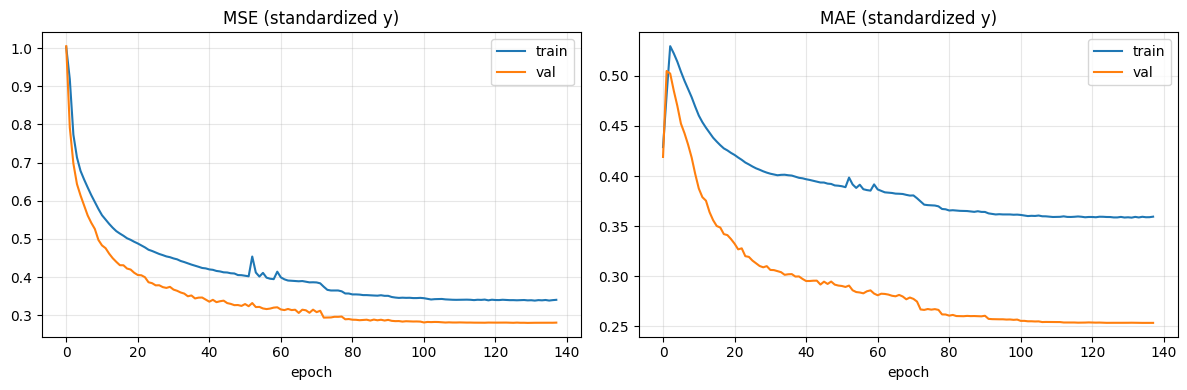

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["mse"], label="train")
axes[0].plot(history.history["val_mse"], label="val")
axes[0].set_title("MSE (standardized y)")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["mae"], label="train")
axes[1].plot(history.history["val_mae"], label="val")
axes[1].set_title("MAE (standardized y)")
axes[1].set_xlabel("epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Evaluate on original displacement scale

In [8]:
y_class_test_2d = y_class_test.reshape(-1, 1)

y_pred_std = model.predict(
    {"pose": X_pose_test, "class_id": y_class_test_2d},
    verbose=0,
).astype(np.float32)

y_pred = y_pred_std * y_std + y_mean
y_true = y_test * y_std + y_mean

mse = float(np.mean((y_true - y_pred) ** 2))
rmse = float(np.sqrt(mse))
mae = float(np.mean(np.abs(y_true - y_pred)))
r2 = r2_score_np(y_true, y_pred)

print(f"MSE:  {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"R2:   {r2:.6f}")

n_coords = int(metadata.get("n_coords", 3))
n_landmarks = int(metadata["n_landmarks"])

err = np.abs(y_true - y_pred)
err_joints = err.reshape(-1, n_landmarks, n_coords)
joint_mae = err_joints.mean(axis=0)

print(f"\nPer-joint MAE (n_coords={n_coords}):")
for j in range(n_landmarks):
    if n_coords == 3:
        print(
            f"  joint {j:02d}: {joint_mae[j,0]:.6f}, {joint_mae[j,1]:.6f}, {joint_mae[j,2]:.6f}"
        )
    else:
        print(f"  joint {j:02d}: {joint_mae[j,0]:.6f}, {joint_mae[j,1]:.6f}")


MSE:  0.000194
RMSE: 0.013944
MAE:  0.006682
R2:   0.721237

Per-joint MAE (n_coords=2):
  joint 00: 0.004804, 0.005953
  joint 01: 0.004978, 0.006059
  joint 02: 0.005979, 0.007160
  joint 03: 0.005787, 0.006828
  joint 04: 0.007284, 0.008724
  joint 05: 0.007066, 0.008739
  joint 06: 0.004198, 0.005321
  joint 07: 0.004120, 0.005307
  joint 08: 0.005984, 0.007855
  joint 09: 0.005922, 0.007761
  joint 10: 0.007059, 0.009989
  joint 11: 0.007174, 0.010322


## Save final weights (in addition to best checkpoint)

In [9]:
final_path = models_dir / "lstm_embedding_pose_correction_final.keras"
model.save(final_path)
print(f"Saved: {final_path}")


Saved: models/lstm_embedding_pose_correction_final.keras
